Mounted at /content/drive
Dataset shape: (545, 13)

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Number of samples: 545
Number of

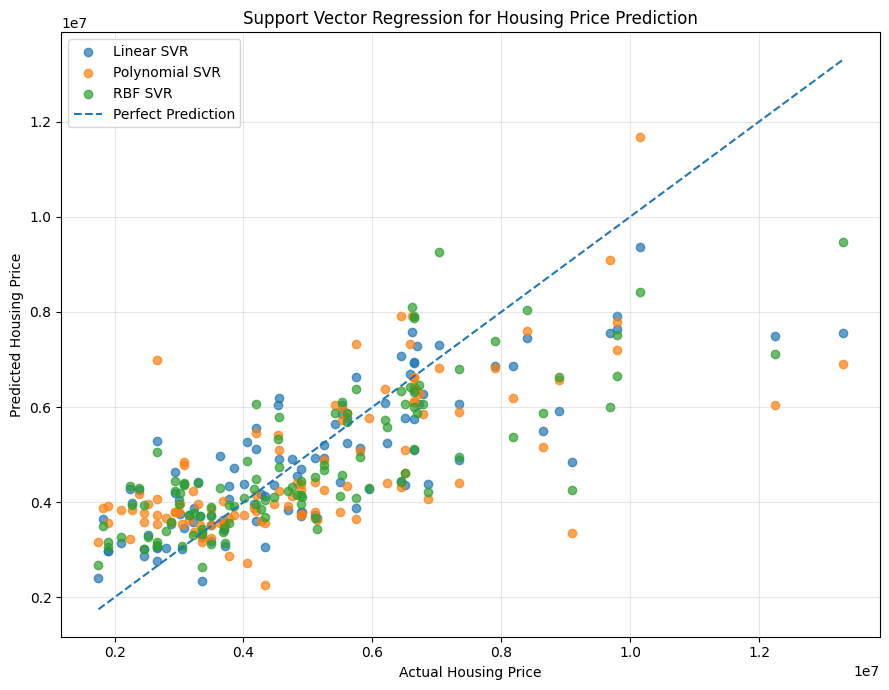


                   BEST SVR MODEL

Best SVR Model: Linear SVR
R2 Score        : 0.6180
RMSE            : $1,389,562.16
MAE             : $1,000,478.34
Evaluation Loss : 965,441,500,587.389

       HW1 REGULARIZED LINEAR REGRESSION RESULTS

R2 Score        : 0.6437
RMSE            : $1,341,952.91
MAE             : $978,884.58
Evaluation Loss : 900,418,801,475.232

                 FINAL MODEL COMPARISON

Linear SVR
R2 Score        : 0.6180
RMSE            : $1,389,562.16
MAE             : $1,000,478.34
Evaluation Loss : 965,441,500,587.389

Polynomial SVR
R2 Score        : 0.4830
RMSE            : $1,616,550.92
MAE             : $1,137,074.30
Evaluation Loss : 1,306,618,446,425.892

RBF SVR
R2 Score        : 0.5970
RMSE            : $1,427,319.78
MAE             : $1,049,354.94
Evaluation Loss : 1,018,620,879,634.423

HW1 Regularized Linear Regression
R2 Score        : 0.6437
RMSE            : $1,341,952.91
MAE             : $978,884.58
Evaluation Loss : 900,418,801,475.232



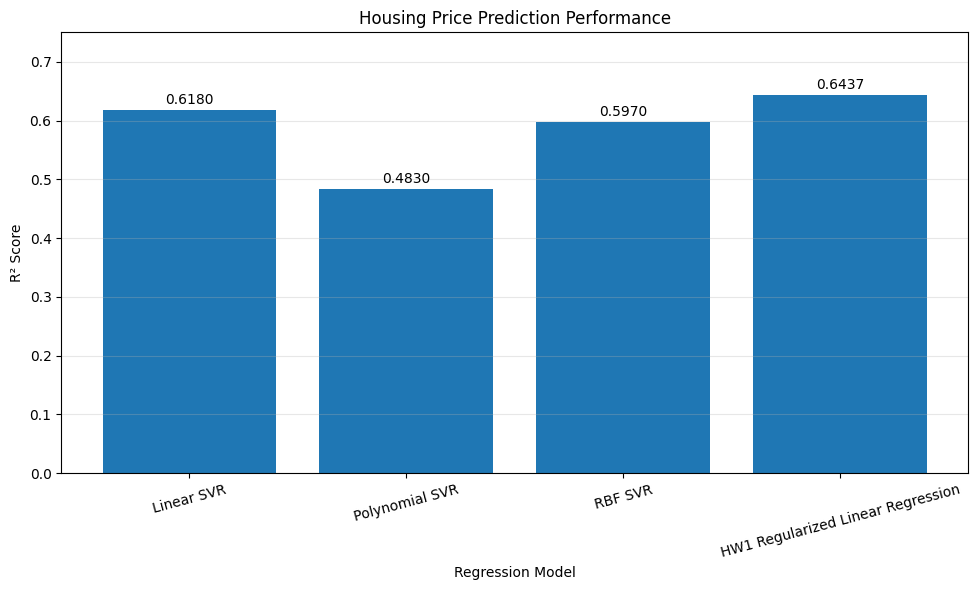

In [1]:
# ============================================================
# Homework 4 - Problem 2
# Housing Price Prediction Using Support Vector Regression
# ============================================================


# ------------------------------------------------------------
# 1. Import Libraries
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)


# ------------------------------------------------------------
# 2. Mount Google Drive
# ------------------------------------------------------------

drive.mount('/content/drive')


# ------------------------------------------------------------
# 3. Load Housing Dataset
# ------------------------------------------------------------

data = pd.read_csv('/content/drive/MyDrive/Housing(1).csv')

print("Dataset shape:", data.shape)

print("\nFirst 5 rows:")
print(data.head())


# ------------------------------------------------------------
# 4. Select Only the Features Required by the Homework
# ------------------------------------------------------------

features = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea'
]


# ------------------------------------------------------------
# 5. Convert Yes/No Variables to 1/0
# ------------------------------------------------------------

binary_features = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for column in binary_features:
    data[column] = data[column].map({
        'yes': 1,
        'no': 0
    })


# ------------------------------------------------------------
# 6. Separate Input Features and Target
# ------------------------------------------------------------

X = data[features]
y = data['price']

print("\nNumber of samples:", X.shape[0])
print("Number of input features:", X.shape[1])


# ------------------------------------------------------------
# 7. 80% Training / 20% Testing Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ------------------------------------------------------------
# 8. Standardize Input Features
# ------------------------------------------------------------

X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)


# ------------------------------------------------------------
# 9. Standardize the Target Price for SVR
#
# Housing prices are measured in millions, while SVR parameters
# such as C and epsilon depend on the scale of the target.
# Therefore, y is also standardized for stable SVR training.
# ------------------------------------------------------------

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    np.array(y_train).reshape(-1, 1)
).ravel()


# ------------------------------------------------------------
# 10. Define SVR Models with Different Kernels
#
# Same three kernel types used in the professor's SVR example:
# Linear, Polynomial, and RBF.
# ------------------------------------------------------------

svr_models = {
    'Linear SVR': SVR(
        kernel='linear'
    ),

    'Polynomial SVR': SVR(
        kernel='poly',
        degree=2
    ),

    'RBF SVR': SVR(
        kernel='rbf'
    )
}


# ------------------------------------------------------------
# 11. Train and Evaluate Each SVR Model
# ------------------------------------------------------------

svr_results = []
svr_predictions = {}


for model_name, model in svr_models.items():

    # Train model
    model.fit(
        X_train_scaled,
        y_train_scaled
    )

    # Predict standardized prices
    y_pred_scaled = model.predict(
        X_test_scaled
    )

    # Convert predictions back to original dollar scale
    y_pred = y_scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).ravel()

    # Store predictions
    svr_predictions[model_name] = y_pred

    # R^2 score
    r2 = r2_score(
        y_test,
        y_pred
    )

    # Mean squared error
    mse = mean_squared_error(
        y_test,
        y_pred
    )

    # Root mean squared error
    rmse = np.sqrt(mse)

    # Mean absolute error
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    # Same evaluation loss form used in Homework 1:
    #
    # J = (1 / 2m) * sum((prediction - actual)^2)
    #
    # Since MSE = (1/m) * sum(error^2),
    # Evaluation Loss = MSE / 2
    evaluation_loss = mse / 2

    svr_results.append([
        model_name,
        r2,
        rmse,
        mae,
        evaluation_loss
    ])


# ------------------------------------------------------------
# 12. SVR Results Table
# ------------------------------------------------------------

svr_results_df = pd.DataFrame(
    svr_results,
    columns=[
        'Model',
        'R2 Score',
        'RMSE',
        'MAE',
        'Evaluation Loss'
    ]
)


print("\n============================================================")
print("                     SVR RESULTS")
print("============================================================\n")

for _, row in svr_results_df.iterrows():

    print(row['Model'])

    print(
        f"R2 Score        : {row['R2 Score']:.4f}"
    )

    print(
        f"RMSE            : ${row['RMSE']:,.2f}"
    )

    print(
        f"MAE             : ${row['MAE']:,.2f}"
    )

    print(
        f"Evaluation Loss : {row['Evaluation Loss']:,.3f}"
    )

    print()


# ============================================================
# FIGURE 1
# Actual Housing Prices vs SVR Predictions
# ============================================================
#
# The professor's sample plots the original data together with
# predictions from RBF, Linear, and Polynomial SVR.
#
# Because this problem has 11 input variables, a single
# two-dimensional regression curve cannot represent the complete
# model. Therefore, actual price vs predicted price is used.
# ============================================================


plt.figure(figsize=(9, 7))


# Linear SVR
plt.scatter(
    y_test,
    svr_predictions['Linear SVR'],
    alpha=0.7,
    label='Linear SVR'
)


# Polynomial SVR
plt.scatter(
    y_test,
    svr_predictions['Polynomial SVR'],
    alpha=0.7,
    label='Polynomial SVR'
)


# RBF SVR
plt.scatter(
    y_test,
    svr_predictions['RBF SVR'],
    alpha=0.7,
    label='RBF SVR'
)


# Perfect prediction reference line
minimum_price = min(
    y_test.min(),
    min(
        np.min(prediction)
        for prediction in svr_predictions.values()
    )
)

maximum_price = max(
    y_test.max(),
    max(
        np.max(prediction)
        for prediction in svr_predictions.values()
    )
)


plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    '--',
    label='Perfect Prediction'
)


plt.xlabel(
    'Actual Housing Price'
)

plt.ylabel(
    'Predicted Housing Price'
)

plt.title(
    'Support Vector Regression for Housing Price Prediction'
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 13. Find Best SVR Kernel Based on R^2
# ------------------------------------------------------------

best_index = svr_results_df[
    'R2 Score'
].idxmax()


best_svr_name = svr_results_df.loc[
    best_index,
    'Model'
]

best_svr_r2 = svr_results_df.loc[
    best_index,
    'R2 Score'
]

best_svr_rmse = svr_results_df.loc[
    best_index,
    'RMSE'
]

best_svr_mae = svr_results_df.loc[
    best_index,
    'MAE'
]

best_svr_loss = svr_results_df.loc[
    best_index,
    'Evaluation Loss'
]


print("\n============================================================")
print("                   BEST SVR MODEL")
print("============================================================\n")

print(
    "Best SVR Model:",
    best_svr_name
)

print(
    f"R2 Score        : {best_svr_r2:.4f}"
)

print(
    f"RMSE            : ${best_svr_rmse:,.2f}"
)

print(
    f"MAE             : ${best_svr_mae:,.2f}"
)

print(
    f"Evaluation Loss : {best_svr_loss:,.3f}"
)


# ============================================================
# PART B
# Homework 1 Regularized Linear Regression
# ============================================================
#
# Reproduce the regularized linear regression model used in HW1:
#
# L2 regularization
# Lambda = 1.0
# Learning rate = 0.01
# Iterations = 1000
#
# Regularization is applied to weights but NOT to the bias.
# ============================================================


# ------------------------------------------------------------
# 14. Add Bias Column
# ------------------------------------------------------------

X_train_lr = np.c_[
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled
]

X_test_lr = np.c_[
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
]


# ------------------------------------------------------------
# 15. Initialize Parameters
# ------------------------------------------------------------

theta = np.zeros(
    X_train_lr.shape[1]
)

learning_rate = 0.01

iterations = 1000

lambda_reg = 1.0

m = len(y_train)


# ------------------------------------------------------------
# 16. Train L2-Regularized Linear Regression
# ------------------------------------------------------------

for iteration in range(iterations):

    # Predictions
    predictions = (
        X_train_lr @ theta
    )

    # Error
    error = (
        predictions -
        np.array(y_train)
    )

    # Gradient of MSE loss
    gradient = (
        X_train_lr.T @ error
    ) / m

    # Add L2 regularization to weights only
    # Bias theta[0] is NOT regularized
    gradient[1:] += (
        lambda_reg / m
    ) * theta[1:]

    # Gradient descent update
    theta -= (
        learning_rate *
        gradient
    )


# ------------------------------------------------------------
# 17. Evaluate Homework 1 Regularized Linear Regression
# ------------------------------------------------------------

lr_predictions = (
    X_test_lr @ theta
)


lr_r2 = r2_score(
    y_test,
    lr_predictions
)


lr_mse = mean_squared_error(
    y_test,
    lr_predictions
)


lr_rmse = np.sqrt(
    lr_mse
)


lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)


# Same validation/evaluation loss used in HW1
lr_evaluation_loss = (
    lr_mse / 2
)


print("\n============================================================")
print("       HW1 REGULARIZED LINEAR REGRESSION RESULTS")
print("============================================================\n")

print(
    f"R2 Score        : {lr_r2:.4f}"
)

print(
    f"RMSE            : ${lr_rmse:,.2f}"
)

print(
    f"MAE             : ${lr_mae:,.2f}"
)

print(
    f"Evaluation Loss : {lr_evaluation_loss:,.3f}"
)


# ------------------------------------------------------------
# 18. Final Comparison Table
# ------------------------------------------------------------

comparison_df = pd.concat([
    svr_results_df[
        [
            'Model',
            'R2 Score',
            'RMSE',
            'MAE',
            'Evaluation Loss'
        ]
    ],

    pd.DataFrame({
        'Model': [
            'HW1 Regularized Linear Regression'
        ],

        'R2 Score': [
            lr_r2
        ],

        'RMSE': [
            lr_rmse
        ],

        'MAE': [
            lr_mae
        ],

        'Evaluation Loss': [
            lr_evaluation_loss
        ]
    })

], ignore_index=True)


print("\n============================================================")
print("                 FINAL MODEL COMPARISON")
print("============================================================\n")


for _, row in comparison_df.iterrows():

    print(row['Model'])

    print(
        f"R2 Score        : {row['R2 Score']:.4f}"
    )

    print(
        f"RMSE            : ${row['RMSE']:,.2f}"
    )

    print(
        f"MAE             : ${row['MAE']:,.2f}"
    )

    print(
        f"Evaluation Loss : {row['Evaluation Loss']:,.3f}"
    )

    print()


# ============================================================
# FIGURE 2
# R^2 Comparison:
# SVR Kernels vs HW1 Regularized Linear Regression
# ============================================================

plt.figure(
    figsize=(10, 6)
)


bars = plt.bar(
    comparison_df['Model'],
    comparison_df['R2 Score']
)


plt.xlabel(
    'Regression Model'
)

plt.ylabel(
    'R² Score'
)

plt.title(
    'Housing Price Prediction Performance'
)

plt.ylim(
    0,
    0.75
)

plt.xticks(
    rotation=15
)


# Display R^2 values above bars
for bar, value in zip(
    bars,
    comparison_df['R2 Score']
):

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,

        bar.get_height() + 0.01,

        f'{value:.4f}',

        ha='center'
    )


plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.show()